In [3]:
import pandas as pd

df = pd.read_csv('../datasets/Iris.csv')

In [7]:
import numpy as np
import statistics as st

dataset = df['SepalLengthCm']

print(np.mean(dataset))
print(np.median(dataset))
print(st.mode(dataset))
print(np.var(dataset))
print(np.ptp(dataset))

5.843333333333334
5.8
5.0
0.6811222222222223
3.6000000000000005


In [3]:
import pandas as pd

df=pd.DataFrame({'data' : dataset})

Q1 = df.quantile(0.25).values[0]
Q3 = df.quantile(0.75).values[0]

IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

5.1
6.4
1.3000000000000007


In [5]:
lower_bound = int((Q1 - 1.5 * IQR))
upper_bound = int((Q3 + 1.5 * IQR))

print(lower_bound)
print(upper_bound)

filtered = df.query("@lower_bound <= data <= @upper_bound")

3
8


<Axes: >

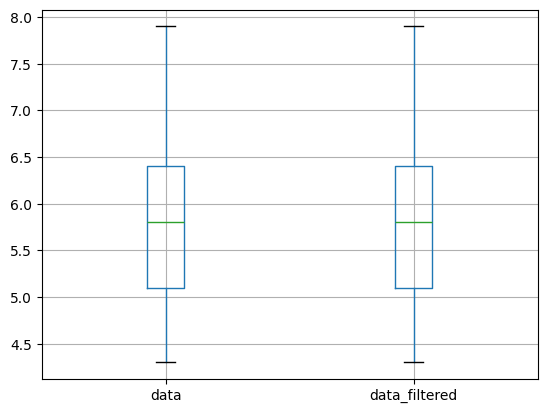

In [6]:
df.join(filtered, rsuffix='_filtered').boxplot()

In [7]:
print(df.query("(data >= @upper_bound) | (data <= @lower_bound)"))

Empty DataFrame
Columns: [data]
Index: []


Loading Super Store dataset...
Dataset loaded successfully!

SUPER STORE DATASET - BASIC INFORMATION
Dataset Shape: 51,290 rows × 23 columns
Memory Usage: 42.41 MB
Date Range: 2011-01-01 to 2014-12-31
Unique Customers: 795
Unique Products: 3,788
Markets Covered: Africa, APAC, EMEA, EU, Canada, LATAM, US

Missing Values Summary:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

NUMERICAL VARIABLES - DESCRIPTIVE STATISTICS
Basic Descriptive Statistics:
          sales  quantity  discount    profit  shipping_cost  days_to_ship  \
count  51290.00  51290.00  51290.00  51290.00       51290.00      51290.00   
mean     246.50      3.48      0.14     28.64          26.38          3.97   
std      487.57      2.28      0.21    174.42          57.30          1.73   
min        0.00      1.00      0.00  -6599.98           0.00          0.00   
25%       31.00      2.00      0.00      0.00           2.61          3.00   
50%       85.00      3.00      0.00      9.24           7.79   

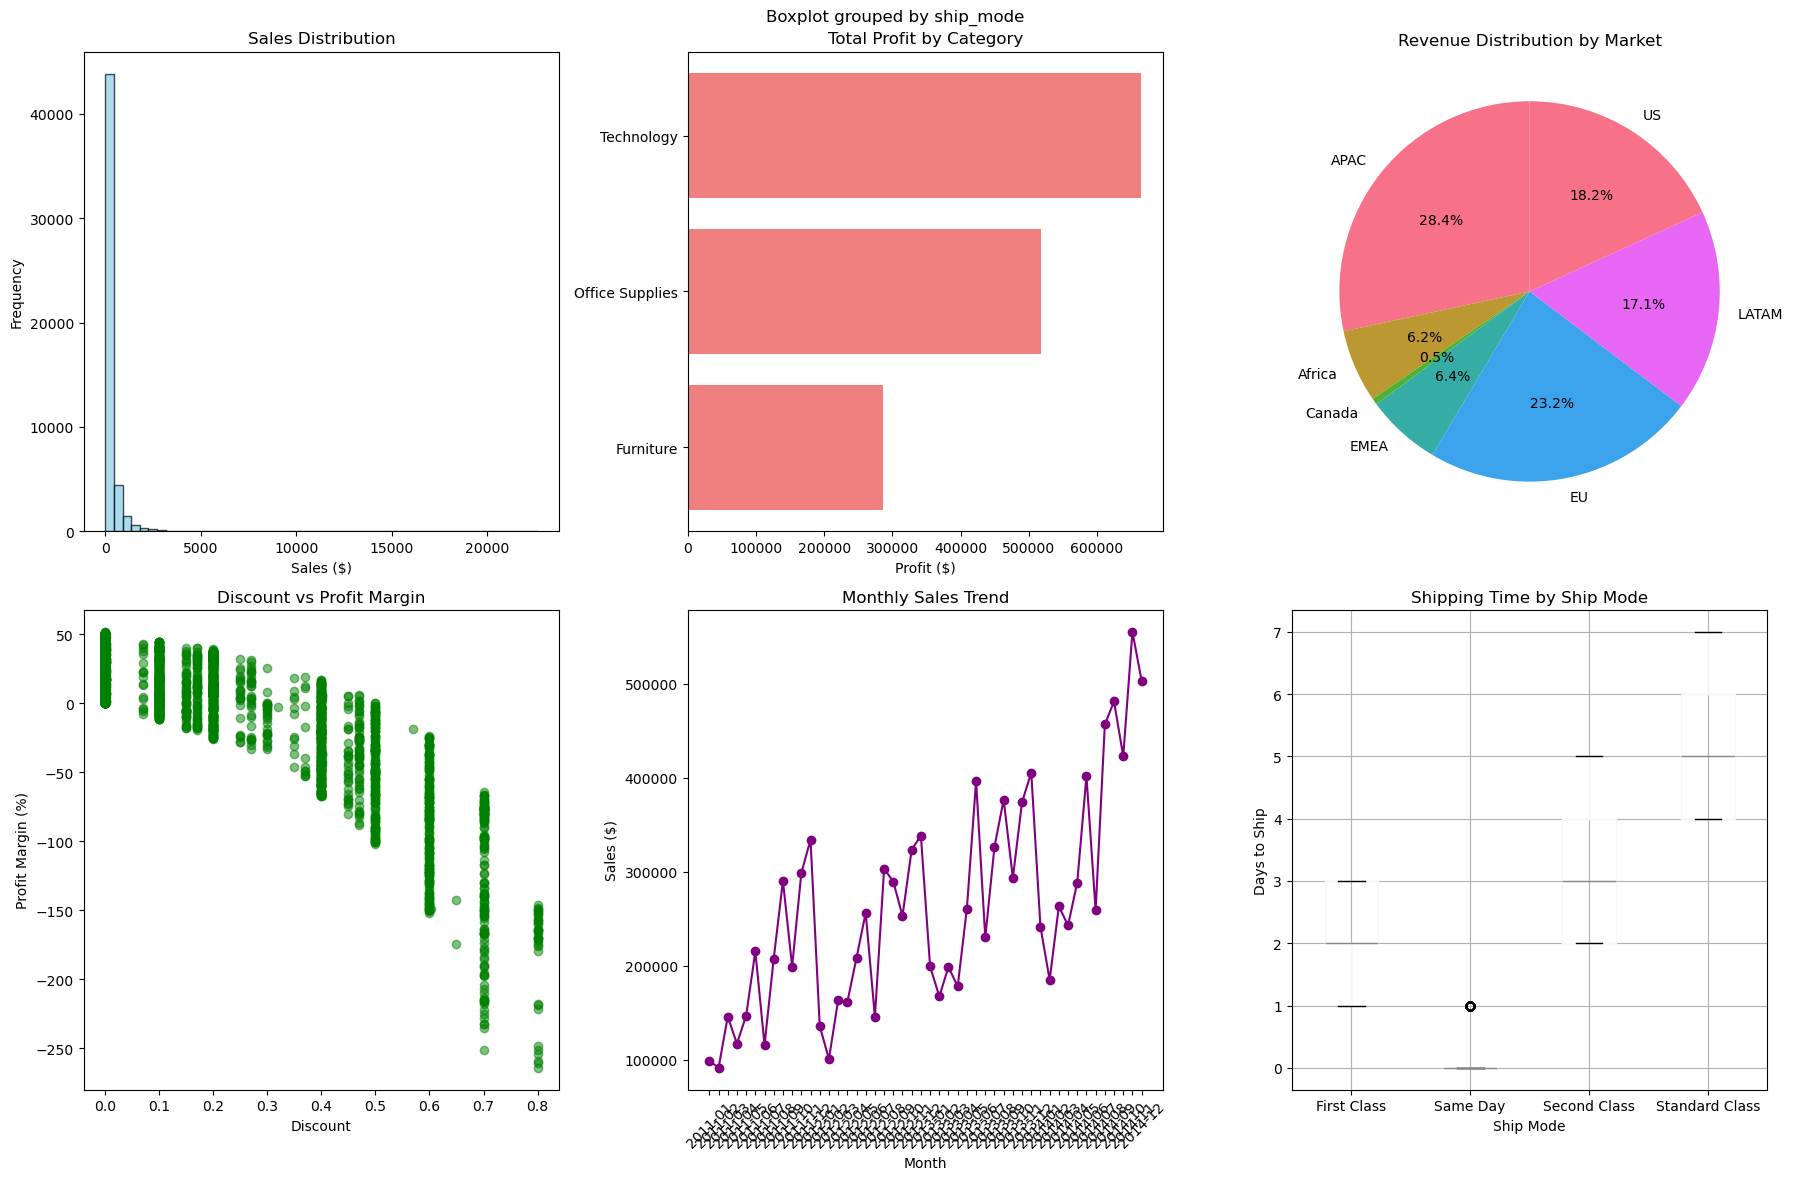

Visualizations generated successfully!

ANALYSIS COMPLETE!
All descriptive statistics have been generated.
Check the visualizations for additional insights.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

def load_and_prepare_data(filepath):
    """Load and prepare the Super Store dataset"""
    # Read the CSV file with proper encoding
    df = pd.read_csv(filepath, encoding='cp1252')
    
    # Convert date columns to datetime with day-first format
    df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
    df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True, errors='coerce')
    
    # Convert sales to numeric (remove any currency symbols if present)
    df['sales'] = pd.to_numeric(df['sales'].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')
    
    # Calculate additional metrics
    df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days
    df['profit_margin'] = (df['profit'] / df['sales'] * 100).round(2)
    
    return df

def basic_info_summary(df):
    """Generate basic dataset information"""
    print("=" * 60)
    print("SUPER STORE DATASET - BASIC INFORMATION")
    print("=" * 60)
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Date Range: {df['order_date'].min().strftime('%Y-%m-%d')} to {df['order_date'].max().strftime('%Y-%m-%d')}")
    print(f"Unique Customers: {df['customer_name'].nunique():,}")
    print(f"Unique Products: {df['product_name'].nunique():,}")
    print(f"Markets Covered: {', '.join(df['market'].unique())}")
    
    print("\nMissing Values Summary:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_df[missing_df['Missing Count'] > 0])
    print()

def numerical_statistics(df):
    """Comprehensive numerical statistics"""
    print("=" * 60)
    print("NUMERICAL VARIABLES - DESCRIPTIVE STATISTICS")
    print("=" * 60)
    
    numerical_cols = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'days_to_ship', 'profit_margin']
    
    # Basic descriptive statistics
    desc_stats = df[numerical_cols].describe()
    print("Basic Descriptive Statistics:")
    print(desc_stats.round(2))
    
    # Additional statistics
    print("\nAdditional Statistical Measures:")
    additional_stats = pd.DataFrame({
        'Skewness': df[numerical_cols].skew(),
        'Kurtosis': df[numerical_cols].kurtosis(),
        'Variance': df[numerical_cols].var(),
        'Range': df[numerical_cols].max() - df[numerical_cols].min(),
        'IQR': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)
    }).round(3)
    print(additional_stats)
    
    # Outlier detection using IQR method
    print("\nOutlier Analysis (IQR Method):")
    outlier_summary = []
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary.append({
            'Variable': col,
            'Outliers Count': len(outliers),
            'Outliers %': round(len(outliers) / len(df) * 100, 2),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2)
        })
    
    outlier_df = pd.DataFrame(outlier_summary)
    print(outlier_df)
    print()

def categorical_statistics(df):
    """Comprehensive categorical statistics"""
    print("=" * 60)
    print("CATEGORICAL VARIABLES - DESCRIPTIVE STATISTICS")
    print("=" * 60)
    
    categorical_cols = ['ship_mode', 'segment', 'market', 'region', 'category', 'sub_category', 'order_priority']
    
    for col in categorical_cols:
        print(f"\n{col.upper().replace('_', ' ')} Distribution:")
        value_counts = df[col].value_counts()
        percentages = (value_counts / len(df) * 100).round(2)
        
        summary_df = pd.DataFrame({
            'Count': value_counts,
            'Percentage': percentages
        })
        print(summary_df)
        print(f"Unique values: {df[col].nunique()}")

def business_insights(df):
    """Generate key business insights"""
    print("=" * 60)
    print("KEY BUSINESS INSIGHTS")
    print("=" * 60)
    
    # Revenue insights
    total_revenue = df['sales'].sum()
    total_profit = df['profit'].sum()
    avg_order_value = df['sales'].mean()
    
    print(f"Financial Summary:")
    print(f"  Total Revenue: ${total_revenue:,.2f}")
    print(f"  Total Profit: ${total_profit:,.2f}")
    print(f"  Overall Profit Margin: {(total_profit/total_revenue)*100:.2f}%")
    print(f"  Average Order Value: ${avg_order_value:.2f}")
    
    # Top performers
    print(f"\nTop Performing Categories by Revenue:")
    category_revenue = df.groupby('category')['sales'].sum().sort_values(ascending=False)
    for i, (category, revenue) in enumerate(category_revenue.head(3).items(), 1):
        print(f"  {i}. {category}: ${revenue:,.2f}")
    
    print(f"\nTop Markets by Revenue:")
    market_revenue = df.groupby('market')['sales'].sum().sort_values(ascending=False)
    for i, (market, revenue) in enumerate(market_revenue.head(3).items(), 1):
        print(f"  {i}. {market}: ${revenue:,.2f}")
    
    # Customer insights
    print(f"\nCustomer Insights:")
    top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(5)
    print(f"  Top customer revenue: ${top_customers.iloc[0]:,.2f}")
    print(f"  Average customer value: ${df.groupby('customer_name')['sales'].sum().mean():.2f}")
    
    # Shipping insights
    print(f"\nShipping Insights:")
    avg_ship_time = df['days_to_ship'].mean()
    print(f"  Average shipping time: {avg_ship_time:.1f} days")
    print(f"  Most popular shipping mode: {df['ship_mode'].mode().iloc[0]}")

def correlation_analysis(df):
    """Analyze correlations between numerical variables"""
    print("=" * 60)
    print("CORRELATION ANALYSIS")
    print("=" * 60)
    
    numerical_cols = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'days_to_ship', 'profit_margin']
    correlation_matrix = df[numerical_cols].corr()
    
    print("Correlation Matrix:")
    print(correlation_matrix.round(3))
    
    # Find strongest correlations
    print("\nStrongest Correlations (absolute value > 0.3):")
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.3:
                strong_corr.append({
                    'Variable 1': correlation_matrix.columns[i],
                    'Variable 2': correlation_matrix.columns[j],
                    'Correlation': round(corr_val, 3)
                })
    
    if strong_corr:
        strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
        print(strong_corr_df)
    else:
        print("No strong correlations found (threshold: |r| > 0.3)")

def create_visualizations(df):
    """Create key visualizations"""
    print("=" * 60)
    print("GENERATING VISUALIZATIONS")
    print("=" * 60)
    
    # Set up the plotting area
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Super Store Dataset - Key Visualizations', fontsize=16, fontweight='bold')
    
    # 1. Sales distribution
    axes[0, 0].hist(df['sales'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Sales Distribution')
    axes[0, 0].set_xlabel('Sales ($)')
    axes[0, 0].set_ylabel('Frequency')
    
    # 2. Profit by Category
    category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=True)
    axes[0, 1].barh(category_profit.index, category_profit.values, color='lightcoral')
    axes[0, 1].set_title('Total Profit by Category')
    axes[0, 1].set_xlabel('Profit ($)')
    
    # 3. Sales by Market
    market_sales = df.groupby('market')['sales'].sum()
    axes[0, 2].pie(market_sales.values, labels=market_sales.index, autopct='%1.1f%%', startangle=90)
    axes[0, 2].set_title('Revenue Distribution by Market')
    
    # 4. Discount vs Profit Margin scatter plot
    sample_data = df.sample(n=min(5000, len(df)))  # Sample for performance
    axes[1, 0].scatter(sample_data['discount'], sample_data['profit_margin'], alpha=0.5, color='green')
    axes[1, 0].set_title('Discount vs Profit Margin')
    axes[1, 0].set_xlabel('Discount')
    axes[1, 0].set_ylabel('Profit Margin (%)')
    
    # 5. Monthly sales trend
    monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
    axes[1, 1].plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='purple')
    axes[1, 1].set_title('Monthly Sales Trend')
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Sales ($)')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    # 6. Shipping time by ship mode
    df.boxplot(column='days_to_ship', by='ship_mode', ax=axes[1, 2])
    axes[1, 2].set_title('Shipping Time by Ship Mode')
    axes[1, 2].set_xlabel('Ship Mode')
    axes[1, 2].set_ylabel('Days to Ship')
    
    plt.tight_layout()
    plt.show()
    print("Visualizations generated successfully!")

print("Loading Super Store dataset...")
try:
    df = load_and_prepare_data('../datasets/super_store_orders.csv')  # Update path as needed
    print("Dataset loaded successfully!\n")
    
    # Run all analyses
    basic_info_summary(df)
    numerical_statistics(df)
    categorical_statistics(df)
    business_insights(df)
    correlation_analysis(df)
    create_visualizations(df)
    
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE!")
    print("=" * 60)
    print("All descriptive statistics have been generated.")
    print("Check the visualizations for additional insights.")
    
except FileNotFoundError:
    print("Error: Could not find 'super_store_orders.csv' file.")
    print("Please ensure the file is in the same directory as this script.")
except Exception as e:
    print(f"An error occurred: {str(e)}")
    print("Please check your data file format and try again.")